In [18]:
import sys
from pathlib import Path

ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import settings as S
from src.models.gruvae.dataset_gruvae import build_svara_sequences, INPUT_DIM

In [19]:
RECORDING_ID = "srs_v1_bdn_sav"
TONIC_HZ     = S.SARASUDA_TONICS[RECORDING_ID]

svaras = build_svara_sequences(recording_id=RECORDING_ID, tonic_hz=TONIC_HZ)
print(f"{len(svaras)} svaras built")

581 svaras built


## Embedding matrix d'una svara

Cada svara és una matriu `(n_segments, 6)`.  
Columnes: `[CP, SIL, STA, dur_rel, total_dur_sec, cents_norm]`

In [20]:
COL_NAMES  = ["CP", "SIL", "STA", "dur_rel", "total_dur_sec", "cents_norm"]
SEG_COLORS = {"CP": "green", "SIL": "grey", "STA": "orange"}
TYPE_LABELS = ["CP", "SIL", "STA"]


def plot_embedding(svara: dict, ax_heat=None, ax_bars=None):
    seq   = svara["sequence"]
    label = svara["svara_label"]
    n_seg = seq.shape[0]
    types     = [TYPE_LABELS[int(seq[i, :3].argmax())] for i in range(n_seg)]
    dur_rel   = seq[:, 3]
    total_dur = float(seq[0, 4])
    cents     = seq[:, 5] * 1200.0

    if ax_heat is not None:
        im = ax_heat.imshow(seq, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
        ax_heat.set_xticks(range(INPUT_DIM))
        ax_heat.set_xticklabels(COL_NAMES, fontsize=8, rotation=30, ha="right")
        ax_heat.set_ylabel("segment", fontsize=8)
        ax_heat.set_title(f"{label}  |  {n_seg} segs  |  {total_dur:.2f}s", fontsize=9)
        plt.colorbar(im, ax=ax_heat)

    if ax_bars is not None:
        colors = [SEG_COLORS[t] for t in types]
        bars = ax_bars.bar(range(n_seg), dur_rel, color=colors, edgecolor="black", linewidth=0.5)
        for i, (bar, c) in enumerate(zip(bars, cents)):
            if np.isfinite(c):
                ax_bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                             f"{c:+.0f}c", ha="center", va="bottom", fontsize=6, rotation=90)
        ax_bars.set_xlabel("segment index", fontsize=8)
        ax_bars.set_ylabel("dur_rel", fontsize=8)
        ax_bars.set_title("Durada relativa per segment", fontsize=9)
        handles = [mpatches.Patch(color=c, label=t) for t, c in SEG_COLORS.items()]
        ax_bars.legend(handles=handles, fontsize=7, loc="upper right")

In [21]:
IDX = 0
svara = svaras[IDX]
print(f"label={svara['svara_label']}  t=[{svara['t_start']:.2f}, {svara['t_end']:.2f}]")
print(f"sequence shape: {svara['sequence'].shape}")
print()
seq = svara["sequence"]
print(f"{'seg':>3}  {'type':4}  {'dur_rel':>8}  {'total_dur':>9}  {'cents_norm':>10}  {'cents':>8}")
print("-" * 55)
for i in range(seq.shape[0]):
    t = TYPE_LABELS[int(seq[i, :3].argmax())]
    print(f"{i:>3}  {t:4}  {seq[i,3]:>8.3f}  {seq[i,4]:>9.3f}  {seq[i,5]:>10.4f}  {seq[i,5]*1200:>+8.1f}")

label=S  t=[3.81, 4.76]
sequence shape: (11, 6)

seg  type   dur_rel  total_dur  cents_norm     cents
-------------------------------------------------------
  0  SIL      0.032      0.950      0.0057      +6.9
  1  STA      0.011      0.950      0.0057      +6.9
  2  CP       0.505      0.950      0.0035      +4.2
  3  STA      0.063      0.950      0.0027      +3.3
  4  STA      0.021      0.950     -0.0506     -60.8
  5  STA      0.011      0.950     -0.0355     -42.7
  6  SIL      0.147      0.950     -0.0355     -42.7
  7  STA      0.032      0.950     -0.1037    -124.4
  8  STA      0.063      0.950     -0.0029      -3.5
  9  STA      0.105      0.950     -0.1327    -159.2
 10  STA      0.011      0.950      0.0562     +67.4


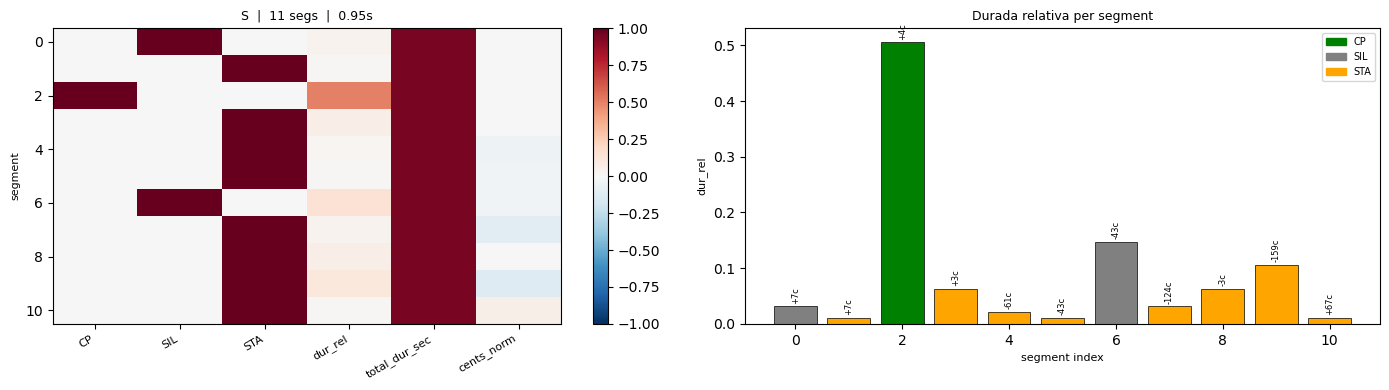

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plot_embedding(svara, ax_heat=ax1, ax_bars=ax2)
plt.tight_layout()
plt.show()

## Vista de múltiples svaras

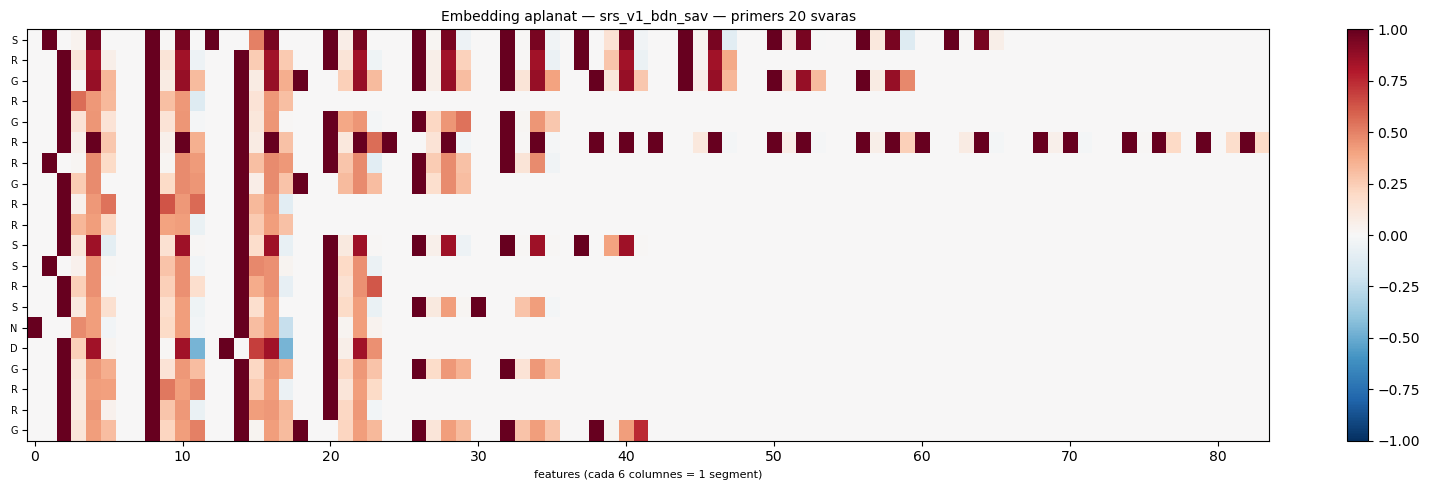

In [23]:
N = 20
MAX_SEG = max(s["sequence"].shape[0] for s in svaras[:N])
mat = np.zeros((N, MAX_SEG * INPUT_DIM))
labels = []
for i, s in enumerate(svaras[:N]):
    seq = s["sequence"]
    flat = seq.flatten()
    mat[i, :len(flat)] = flat
    labels.append(s["svara_label"])

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(mat, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_yticks(range(N))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel(f"features (cada {INPUT_DIM} columnes = 1 segment)", fontsize=8)
ax.set_title(f"Embedding aplanat — {RECORDING_ID} — primers {N} svaras", fontsize=10)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Distribució de n_segments per svara

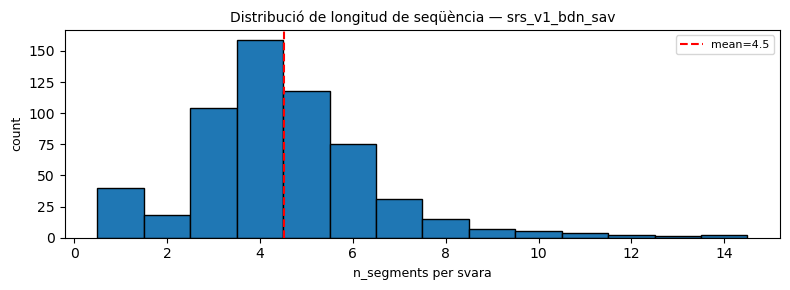

min=1  max=14  mean=4.5  median=4


In [24]:
lengths = [s["sequence"].shape[0] for s in svaras]
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lengths, bins=range(1, max(lengths) + 2), edgecolor="black", align="left")
ax.set_xlabel("n_segments per svara", fontsize=9)
ax.set_ylabel("count", fontsize=9)
ax.set_title(f"Distribució de longitud de seqüència — {RECORDING_ID}", fontsize=10)
ax.axvline(np.mean(lengths), color="red", lw=1.5, ls="--", label=f"mean={np.mean(lengths):.1f}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"min={min(lengths)}  max={max(lengths)}  mean={np.mean(lengths):.1f}  median={np.median(lengths):.0f}")

---
## Anàlisi de distribució de variables del dataset

Càrrega de **tot el corpus** per tenir estadístiques representatives.

In [ ]:
from src.models.gruvae.dataset_gruvae import build_corpus_sequences

all_svaras = build_corpus_sequences()
print(f"Total svaras corpus: {len(all_svaras)}")

# Aplanar totes les seqüències a llista de segments
all_types      = []
all_dur_rel    = []
all_cents_norm = []
all_lengths    = []

for s in all_svaras:
    seq = s["sequence"]   # (n_seg, 6)
    all_lengths.append(seq.shape[0])
    for row in seq:
        all_types.append(TYPE_LABELS[int(row[:3].argmax())])
        all_dur_rel.append(float(row[3]))
        all_cents_norm.append(float(row[5]))

all_dur_rel    = np.array(all_dur_rel)
all_cents_norm = np.array(all_cents_norm)
all_lengths    = np.array(all_lengths)
print(f"Total segments: {len(all_types)}")

  srs_v1_bdn_sav...
  srs_v1_drn_sav...
  srs_v1_psn_sav...
  srs_v1_rkm_sav...


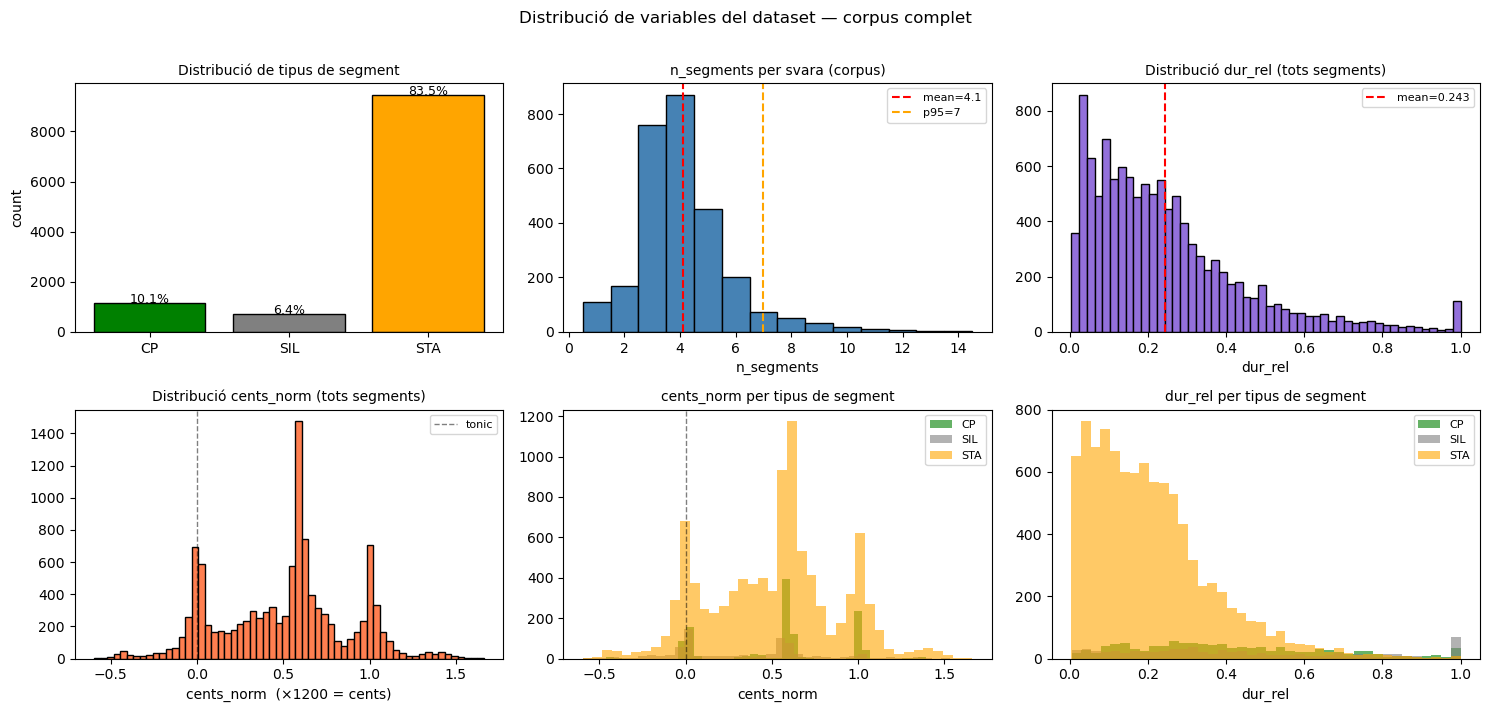

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

# --- 1. Tipus de segments ---
ax = axes[0, 0]
type_counts = {t: all_types.count(t) for t in TYPE_LABELS}
total_segs = len(all_types)
bars = ax.bar(type_counts.keys(), type_counts.values(),
              color=[SEG_COLORS[t] for t in TYPE_LABELS], edgecolor="black")
for bar, (t, c) in zip(bars, type_counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{100*c/total_segs:.1f}%", ha="center", fontsize=9)
ax.set_title("Distribució de tipus de segment", fontsize=10)
ax.set_ylabel("count")

# --- 2. n_segments per svara ---
ax = axes[0, 1]
ax.hist(all_lengths, bins=range(1, all_lengths.max() + 2), edgecolor="black", align="left", color="steelblue")
ax.axvline(np.mean(all_lengths), color="red", lw=1.5, ls="--", label=f"mean={np.mean(all_lengths):.1f}")
ax.axvline(np.percentile(all_lengths, 95), color="orange", lw=1.5, ls="--",
           label=f"p95={np.percentile(all_lengths, 95):.0f}")
ax.set_title("n_segments per svara (corpus)", fontsize=10)
ax.set_xlabel("n_segments")
ax.legend(fontsize=8)

# --- 3. dur_rel ---
ax = axes[0, 2]
ax.hist(all_dur_rel, bins=50, edgecolor="black", color="mediumpurple")
ax.axvline(np.mean(all_dur_rel), color="red", lw=1.5, ls="--", label=f"mean={np.mean(all_dur_rel):.3f}")
ax.set_title("Distribució dur_rel (tots segments)", fontsize=10)
ax.set_xlabel("dur_rel")
ax.legend(fontsize=8)

# --- 4. cents_norm ---
ax = axes[1, 0]
ax.hist(all_cents_norm, bins=60, edgecolor="black", color="coral")
ax.axvline(0, color="black", lw=1, ls="--", alpha=0.5, label="tonic")
ax.set_title("Distribució cents_norm (tots segments)", fontsize=10)
ax.set_xlabel("cents_norm  (×1200 = cents)")
ax.legend(fontsize=8)

# --- 5. cents_norm per tipus ---
ax = axes[1, 1]
cents_by_type = {t: [] for t in TYPE_LABELS}
for s in all_svaras:
    for row in s["sequence"]:
        t = TYPE_LABELS[int(row[:3].argmax())]
        cents_by_type[t].append(float(row[5]))
for t, color in SEG_COLORS.items():
    ax.hist(cents_by_type[t], bins=40, alpha=0.6, label=t, color=color, edgecolor="none")
ax.axvline(0, color="black", lw=1, ls="--", alpha=0.5)
ax.set_title("cents_norm per tipus de segment", fontsize=10)
ax.set_xlabel("cents_norm")
ax.legend(fontsize=8)

# --- 6. dur_rel per tipus ---
ax = axes[1, 2]
for t, color in SEG_COLORS.items():
    dur_t = [all_dur_rel[i] for i, tt in enumerate(all_types) if tt == t]
    ax.hist(dur_t, bins=40, alpha=0.6, label=t, color=color, edgecolor="none")
ax.set_title("dur_rel per tipus de segment", fontsize=10)
ax.set_xlabel("dur_rel")
ax.legend(fontsize=8)

plt.suptitle("Distribució de variables del dataset — corpus complet", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Exploració de dur_rel: és discriminatiu?

Per cada svara calculem la fracció de temps dedicada a CP, STA i SIL,
i el nombre de segments STA consecutius (densitat d'ornaments).

In [ ]:
import itertools

svara_stats = []
for s in all_svaras:
    seq   = s["sequence"]   # (n_seg, 6)
    types = [int(seq[i, :3].argmax()) for i in range(len(seq))]   # 0=CP,1=SIL,2=STA

    cp_frac  = float(sum(seq[i, 3] for i in range(len(seq)) if types[i] == 0))
    sta_frac = float(sum(seq[i, 3] for i in range(len(seq)) if types[i] == 2))
    sil_frac = float(sum(seq[i, 3] for i in range(len(seq)) if types[i] == 1))
    n_sta    = sum(1 for t in types if t == 2)

    # Longest consecutive STA run
    max_consec_sta = max(
        (sum(1 for _ in grp) for key, grp in itertools.groupby(types) if key == 2),
        default=0
    )

    svara_stats.append({
        "label":          s["svara_label"],
        "cp_frac":        cp_frac,
        "sta_frac":       sta_frac,
        "sil_frac":       sil_frac,
        "n_sta":          n_sta,
        "max_consec_sta": max_consec_sta,
    })

labels_u = sorted(set(s["label"] for s in svara_stats))
print(f"Svaras: {len(svara_stats)}  |  Labels únics: {len(labels_u)}")

Svaras: 2760  |  Labels únics: 7


/tmp/ipykernel_16864/3508652263.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_label, labels=labels_u, vert=True,


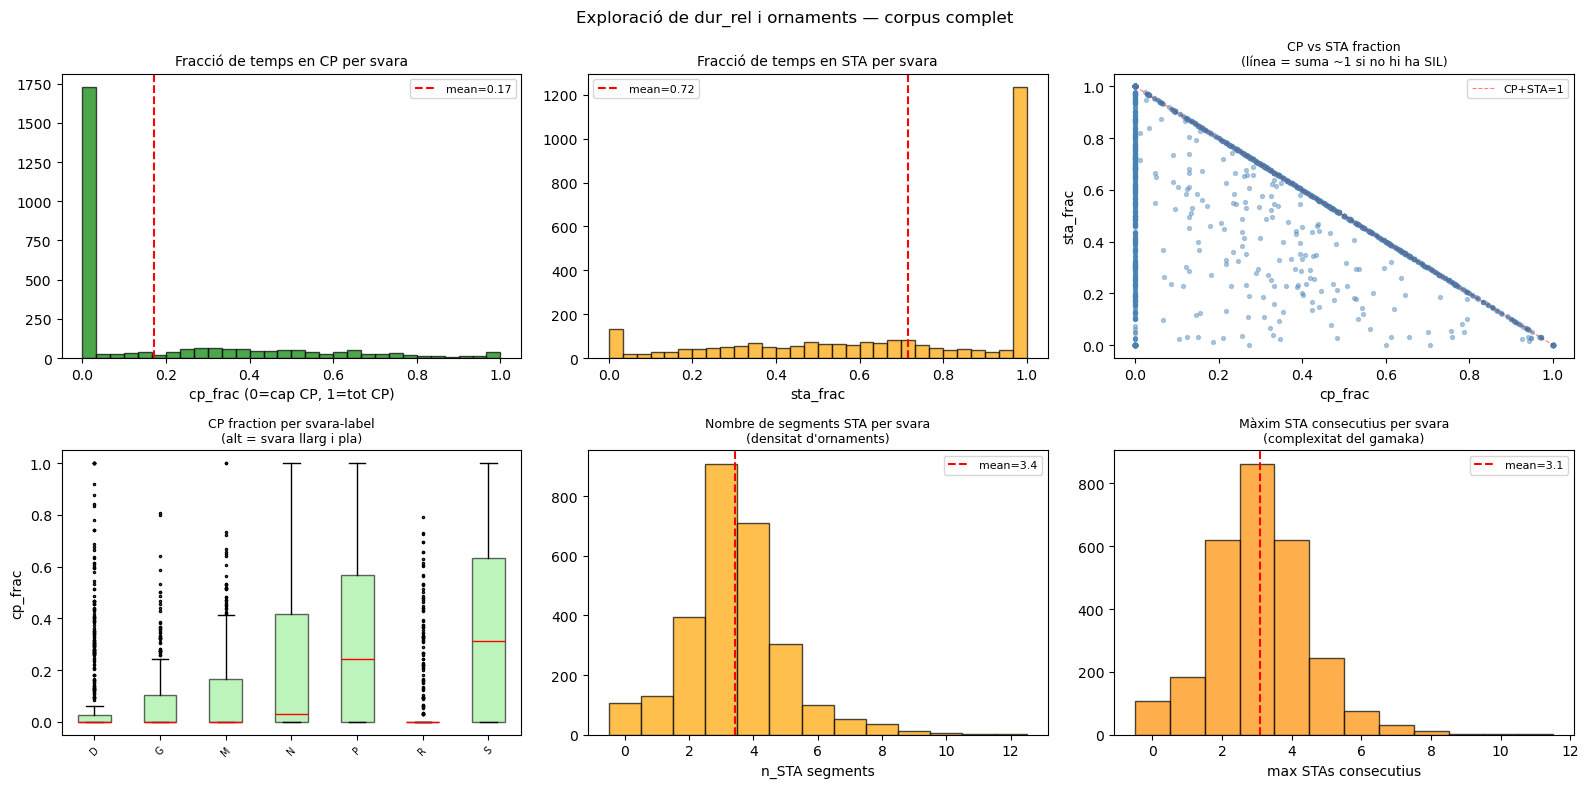

CP fraction:  mean=0.172  std=0.266  min=0.000  max=1.000
STA fraction: mean=0.715  std=0.322  min=0.000  max=1.000
n_STA/svara:  mean=3.4  max=12
Max consec STA: mean=3.1  max=11


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

cp_fracs  = [s["cp_frac"]  for s in svara_stats]
sta_fracs = [s["sta_frac"] for s in svara_stats]
n_stas    = [s["n_sta"]    for s in svara_stats]
max_cstas = [s["max_consec_sta"] for s in svara_stats]

# --- 1. Histograma CP fraction global ---
ax = axes[0, 0]
ax.hist(cp_fracs, bins=30, color="green", edgecolor="black", alpha=0.7)
ax.axvline(np.mean(cp_fracs), color="red", lw=1.5, ls="--", label=f"mean={np.mean(cp_fracs):.2f}")
ax.set_title("Fracció de temps en CP per svara", fontsize=10)
ax.set_xlabel("cp_frac (0=cap CP, 1=tot CP)")
ax.legend(fontsize=8)

# --- 2. Histograma STA fraction global ---
ax = axes[0, 1]
ax.hist(sta_fracs, bins=30, color="orange", edgecolor="black", alpha=0.7)
ax.axvline(np.mean(sta_fracs), color="red", lw=1.5, ls="--", label=f"mean={np.mean(sta_fracs):.2f}")
ax.set_title("Fracció de temps en STA per svara", fontsize=10)
ax.set_xlabel("sta_frac")
ax.legend(fontsize=8)

# --- 3. Scatter CP vs STA fraction ---
ax = axes[0, 2]
ax.scatter(cp_fracs, sta_fracs, s=8, alpha=0.4, color="steelblue")
ax.set_xlabel("cp_frac")
ax.set_ylabel("sta_frac")
ax.set_title("CP vs STA fraction\n(línea = suma ~1 si no hi ha SIL)", fontsize=9)
x_line = np.linspace(0, 1, 50)
ax.plot(x_line, 1 - x_line, "r--", lw=0.8, alpha=0.5, label="CP+STA=1")
ax.legend(fontsize=8)

# --- 4. Boxplot CP fraction per label ---
ax = axes[1, 0]
data_by_label = [[s["cp_frac"] for s in svara_stats if s["label"] == l] for l in labels_u]
ax.boxplot(data_by_label, labels=labels_u, vert=True,
           patch_artist=True, boxprops=dict(facecolor="lightgreen", alpha=0.6),
           medianprops=dict(color="red"), flierprops=dict(marker=".", markersize=3))
ax.set_title("CP fraction per svara-label\n(alt = svara llarg i pla)", fontsize=9)
ax.set_ylabel("cp_frac")
ax.tick_params(axis="x", labelsize=7, rotation=45)

# --- 5. n_sta per svara ---
ax = axes[1, 1]
ax.hist(n_stas, bins=range(0, max(n_stas) + 2), edgecolor="black", color="orange", alpha=0.7, align="left")
ax.set_title("Nombre de segments STA per svara\n(densitat d'ornaments)", fontsize=9)
ax.set_xlabel("n_STA segments")
ax.axvline(np.mean(n_stas), color="red", lw=1.5, ls="--", label=f"mean={np.mean(n_stas):.1f}")
ax.legend(fontsize=8)

# --- 6. Màxim STA consecutius per svara ---
ax = axes[1, 2]
ax.hist(max_cstas, bins=range(0, max(max_cstas) + 2), edgecolor="black",
        color="darkorange", alpha=0.7, align="left")
ax.set_title("Màxim STA consecutius per svara\n(complexitat del gamaka)", fontsize=9)
ax.set_xlabel("max STAs consecutius")
ax.axvline(np.mean(max_cstas), color="red", lw=1.5, ls="--", label=f"mean={np.mean(max_cstas):.1f}")
ax.legend(fontsize=8)

plt.suptitle("Exploració de dur_rel i ornaments — corpus complet", fontsize=12)
plt.tight_layout()
plt.show()

print(f"CP fraction:  mean={np.mean(cp_fracs):.3f}  std={np.std(cp_fracs):.3f}  "
      f"min={min(cp_fracs):.3f}  max={max(cp_fracs):.3f}")
print(f"STA fraction: mean={np.mean(sta_fracs):.3f}  std={np.std(sta_fracs):.3f}  "
      f"min={min(sta_fracs):.3f}  max={max(sta_fracs):.3f}")
print(f"n_STA/svara:  mean={np.mean(n_stas):.1f}  max={max(n_stas)}")
print(f"Max consec STA: mean={np.mean(max_cstas):.1f}  max={max(max_cstas)}")

### Anàlisi per classe de svara (S R G M P D N)

In [ ]:
from scipy.stats import gaussian_kde

def base_class(label: str) -> str:
    """Extreu la classe base (primer caràcter majúscula)."""
    return label[0].upper()

CLASSES = ['S', 'R', 'G', 'M', 'P', 'D', 'N']
cmap_cls = plt.cm.tab10(np.linspace(0, 0.9, len(CLASSES)))
cls_color = dict(zip(CLASSES, cmap_cls))

# Agrupa svara_stats i all_svaras per classe
stats_by_cls  = {c: [s for s in svara_stats if base_class(s["label"]) == c]  for c in CLASSES}
svaras_by_cls = {c: [s for s in all_svaras  if base_class(s["svara_label"]) == c] for c in CLASSES}

# Extreu cents de CP i STA per classe (de all_svaras, col 5 = cents_norm)
cp_cents_cls  = {}
sta_cents_cls = {}
for c in CLASSES:
    cp_c, sta_c = [], []
    for s in svaras_by_cls[c]:
        seq = s["sequence"]   # (n_seg, 6): col 0-2 onehot, col 5 cents_norm
        for row in seq:
            t = int(row[:3].argmax())
            cents = float(row[5]) * 1200.0
            if   t == 0: cp_c.append(cents)
            elif t == 2: sta_c.append(cents)
    cp_cents_cls[c]  = np.array(cp_c)
    sta_cents_cls[c] = np.array(sta_c)

# Resum per consola
print(f"{'Classe':>6}  {'n_svaras':>8}  {'n_sta mean':>10}  {'max_consec mean':>15}  {'CP cents mean':>13}  {'STA cents mean':>14}")
print("-" * 75)
for c in CLASSES:
    ss = stats_by_cls[c]
    if not ss:
        continue
    n_sta_vals    = [s["n_sta"]          for s in ss]
    consec_vals   = [s["max_consec_sta"] for s in ss]
    cp_mean  = cp_cents_cls[c].mean()  if len(cp_cents_cls[c])  else float("nan")
    sta_mean = sta_cents_cls[c].mean() if len(sta_cents_cls[c]) else float("nan")
    print(f"{c:>6}  {len(ss):>8}  {np.mean(n_sta_vals):>10.2f}  {np.mean(consec_vals):>15.2f}  {cp_mean:>13.1f}  {sta_mean:>14.1f}")

Classe  n_svaras  n_sta mean  max_consec mean  CP cents mean  STA cents mean
---------------------------------------------------------------------------
     S       401        2.88             2.44          581.4           517.9
     R       471        3.72             3.43          422.1           451.6
     G       210        3.72             3.40          591.3           613.7
     M       345        3.58             3.35          669.9           547.2
     P       470        3.20             2.69          704.7           652.4
     D       616        3.62             3.33          660.6           693.1
     N       247        3.25             3.02          980.4           927.9


In [ ]:
# Augmenta svara_stats amb total_dur i blocs de STA consecutius
for s, stat in zip(all_svaras, svara_stats):
    seq   = s["sequence"]                     # (n_seg, 6): col 4 = total_dur_sec
    types = [int(seq[j, :3].argmax()) for j in range(len(seq))]

    stat["total_dur"] = float(seq[0, 4])      # durada total svara (s)

    # Blocs de STA consecutius: cada run de STA seguits = 1 bloc
    sta_blocks = []
    for key, grp in itertools.groupby(enumerate(types), key=lambda x: x[1]):
        if key == 2:   # STA
            indices = [idx for idx, _ in grp]
            bloc_dur_rel = sum(float(seq[idx, 3]) for idx in indices)
            bloc_dur_sec = bloc_dur_rel * stat["total_dur"]
            sta_blocks.append({"dur_rel": bloc_dur_rel, "dur_sec": bloc_dur_sec, "n_seg": len(indices)})

    stat["n_sta_blocks"]      = len(sta_blocks)
    stat["sta_blocks"]        = sta_blocks
    stat["avg_block_dur_rel"] = float(np.mean([b["dur_rel"] for b in sta_blocks])) if sta_blocks else 0.0
    stat["avg_block_dur_sec"] = float(np.mean([b["dur_sec"] for b in sta_blocks])) if sta_blocks else 0.0

# Necessari per les cel·les de plots d'aquesta secció
valid_cls = [c for c in CLASSES if stats_by_cls[c]]

print("svara_stats augmentat amb total_dur, n_sta_blocks, sta_blocks")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── ROW 1: STA individual ────────────────────────────────────────────────────

# 1a. Boxplot: proporció de durada STA per classe
ax = axes[0, 0]
data = [[s["sta_frac"] for s in stats_by_cls[c]] for c in valid_cls]
bp = ax.boxplot(data, labels=valid_cls, patch_artist=True,
                medianprops=dict(color="black", lw=2),
                flierprops=dict(marker=".", markersize=3, alpha=0.5))
for patch, c in zip(bp["boxes"], valid_cls):
    patch.set_facecolor(cls_color[c]); patch.set_alpha(0.7)
ax.set_title("Proporció durada STA per classe\n(STA individual)", fontsize=10)
ax.set_ylabel("sta_frac  (0=cap STA, 1=tot STA)")
ax.set_xlabel("classe")

# 1b. Scatter: durada total svara vs proporció STA
ax = axes[0, 1]
for c in valid_cls:
    xs = [s["total_dur"] for s in stats_by_cls[c]]
    ys = [s["sta_frac"]  for s in stats_by_cls[c]]
    ax.scatter(xs, ys, s=10, alpha=0.5, color=cls_color[c], label=c, edgecolors="none")
ax.set_title("Durada total vs proporció STA\n(STA individual, per classe)", fontsize=10)
ax.set_xlabel("total_dur_sec  (durada svara en s)")
ax.set_ylabel("sta_frac")
ax.legend(fontsize=7, ncol=2)

# ── ROW 2: Blocs de STA consecutius ─────────────────────────────────────────

# 2a. Boxplot: durada relativa mitjana per bloc, per classe
ax = axes[1, 0]
data_bloc = [[s["avg_block_dur_rel"] for s in stats_by_cls[c] if s["n_sta_blocks"] > 0]
             for c in valid_cls]
bp2 = ax.boxplot(data_bloc, labels=valid_cls, patch_artist=True,
                 medianprops=dict(color="black", lw=2),
                 flierprops=dict(marker=".", markersize=3, alpha=0.5))
for patch, c in zip(bp2["boxes"], valid_cls):
    patch.set_facecolor(cls_color[c]); patch.set_alpha(0.7)
ax.set_title("Durada relativa mitjana per BLOC STA\n(bloc = run de STAs consecutius)", fontsize=10)
ax.set_ylabel("avg bloc dur_rel")
ax.set_xlabel("classe")

# 2b. Scatter: durada total svara vs nombre de blocs STA
ax = axes[1, 1]
for c in valid_cls:
    xs = [s["total_dur"]    for s in stats_by_cls[c]]
    ys = [s["n_sta_blocks"] for s in stats_by_cls[c]]
    ax.scatter(xs, ys, s=10, alpha=0.5, color=cls_color[c], label=c, edgecolors="none")
ax.set_title("Durada total vs nombre de blocs STA\n(per classe)", fontsize=10)
ax.set_xlabel("total_dur_sec")
ax.set_ylabel("n_sta_blocks  (nombre de grups d'ornaments)")
ax.legend(fontsize=7, ncol=2)
# Afegeix línia de tendència global
all_x = [s["total_dur"]    for s in svara_stats]
all_y = [s["n_sta_blocks"] for s in svara_stats]
m, b_line = np.polyfit(all_x, all_y, 1)
xr = np.linspace(min(all_x), max(all_x), 100)
ax.plot(xr, m*xr + b_line, "k--", lw=1, alpha=0.5, label=f"global trend (slope={m:.2f})")
ax.legend(fontsize=7, ncol=2)

plt.suptitle("Anàlisi de durades STA — individual vs blocs consecutius", fontsize=12)
plt.tight_layout()
plt.show()

# Resum numèric
print(f"\n{'Classe':>6}  {'sta_frac mean':>13}  {'n_blocks mean':>13}  "
      f"{'avg_bloc_dur_rel':>16}  {'avg_bloc_dur_sec':>16}")
print("-" * 70)
for c in valid_cls:
    ss = stats_by_cls[c]
    if not ss: continue
    print(f"{c:>6}  {np.mean([s['sta_frac'] for s in ss]):>13.3f}  "
          f"{np.mean([s['n_sta_blocks'] for s in ss]):>13.2f}  "
          f"{np.mean([s['avg_block_dur_rel'] for s in ss]):>16.3f}  "
          f"{np.mean([s['avg_block_dur_sec'] for s in ss]):>16.3f}")

/tmp/ipykernel_16864/1095735249.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_consec, labels=valid_cls, patch_artist=True,
/tmp/ipykernel_16864/1095735249.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(data_nsta, labels=valid_cls, patch_artist=True,


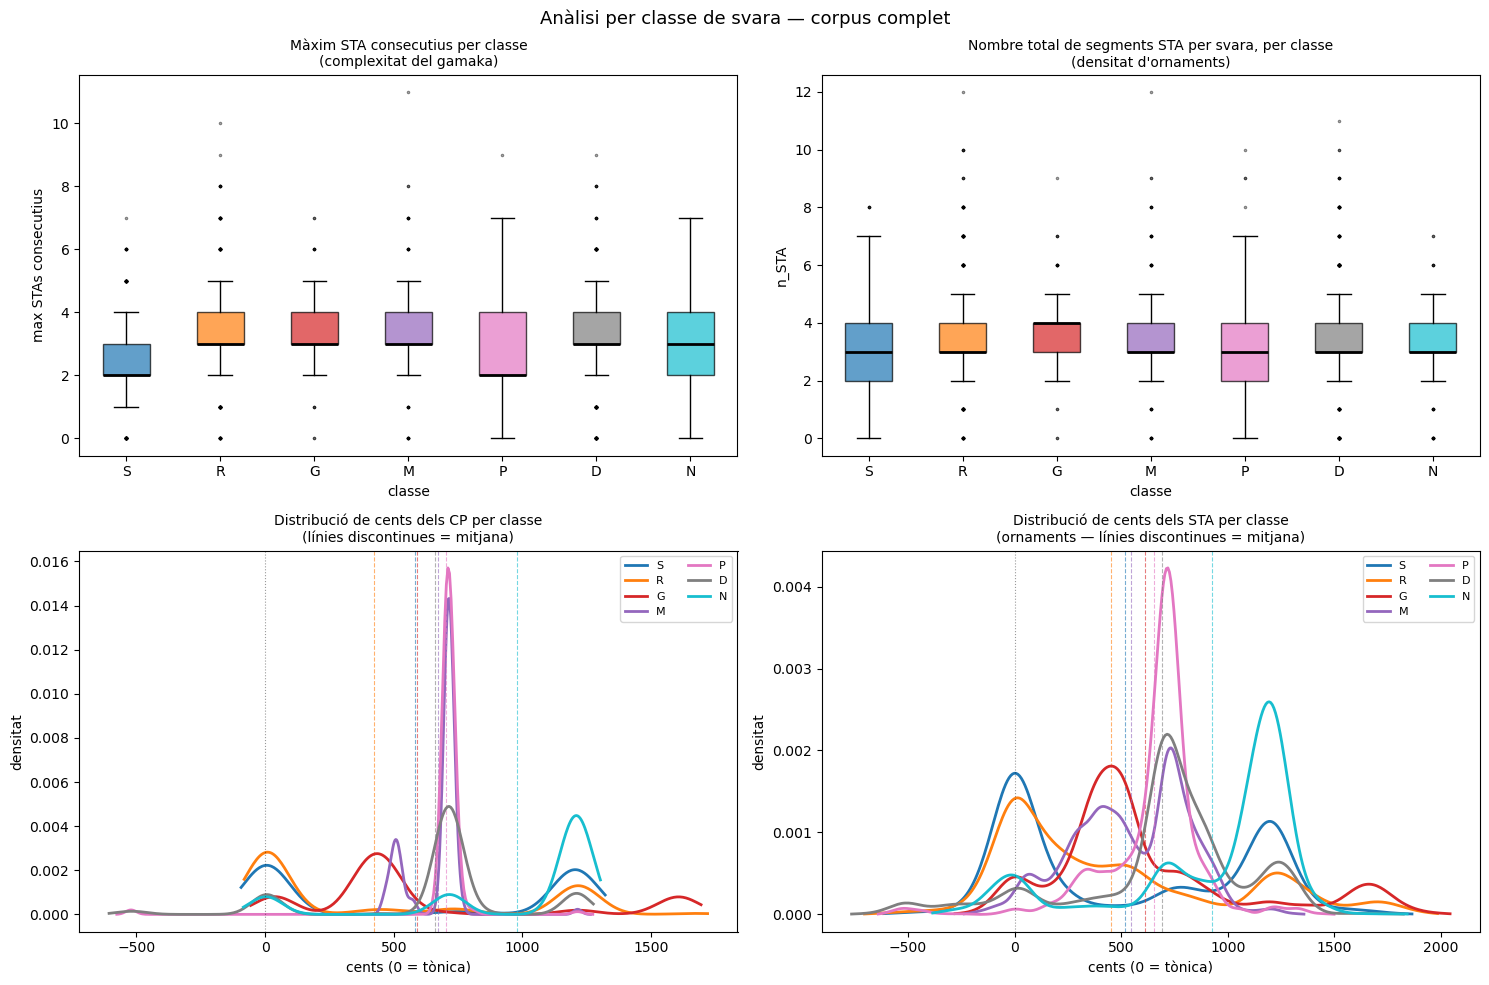

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

valid_cls = [c for c in CLASSES if stats_by_cls[c]]

# --- 1. Boxplot: màxim STA consecutius per classe ---
ax = axes[0, 0]
data_consec = [[s["max_consec_sta"] for s in stats_by_cls[c]] for c in valid_cls]
bp = ax.boxplot(data_consec, labels=valid_cls, patch_artist=True,
                medianprops=dict(color="black", lw=2),
                flierprops=dict(marker=".", markersize=3, alpha=0.5))
for patch, c in zip(bp["boxes"], valid_cls):
    patch.set_facecolor(cls_color[c])
    patch.set_alpha(0.7)
ax.set_title("Màxim STA consecutius per classe\n(complexitat del gamaka)", fontsize=10)
ax.set_ylabel("max STAs consecutius")
ax.set_xlabel("classe")

# --- 2. Boxplot: total n_STA per classe ---
ax = axes[0, 1]
data_nsta = [[s["n_sta"] for s in stats_by_cls[c]] for c in valid_cls]
bp2 = ax.boxplot(data_nsta, labels=valid_cls, patch_artist=True,
                 medianprops=dict(color="black", lw=2),
                 flierprops=dict(marker=".", markersize=3, alpha=0.5))
for patch, c in zip(bp2["boxes"], valid_cls):
    patch.set_facecolor(cls_color[c])
    patch.set_alpha(0.7)
ax.set_title("Nombre total de segments STA per svara, per classe\n(densitat d'ornaments)", fontsize=10)
ax.set_ylabel("n_STA")
ax.set_xlabel("classe")

# --- 3. KDE: valors de cents dels CP per classe ---
ax = axes[1, 0]
for c in valid_cls:
    vals = cp_cents_cls[c]
    if len(vals) < 5:
        continue
    kde = gaussian_kde(vals, bw_method=0.15)
    x   = np.linspace(vals.min() - 50, vals.max() + 50, 300)
    ax.plot(x, kde(x), color=cls_color[c], lw=2, label=c)
    ax.axvline(vals.mean(), color=cls_color[c], lw=0.8, ls="--", alpha=0.6)
ax.set_title("Distribució de cents dels CP per classe\n(línies discontinues = mitjana)", fontsize=10)
ax.set_xlabel("cents (0 = tònica)")
ax.set_ylabel("densitat")
ax.legend(fontsize=8, ncol=2)
ax.axvline(0, color="black", lw=0.8, ls=":", alpha=0.4)

# --- 4. KDE: valors de cents dels STA per classe ---
ax = axes[1, 1]
for c in valid_cls:
    vals = sta_cents_cls[c]
    if len(vals) < 5:
        continue
    kde = gaussian_kde(vals, bw_method=0.15)
    x   = np.linspace(vals.min() - 50, vals.max() + 50, 300)
    ax.plot(x, kde(x), color=cls_color[c], lw=2, label=c)
    ax.axvline(vals.mean(), color=cls_color[c], lw=0.8, ls="--", alpha=0.6)
ax.set_title("Distribució de cents dels STA per classe\n(ornaments — línies discontinues = mitjana)", fontsize=10)
ax.set_xlabel("cents (0 = tònica)")
ax.set_ylabel("densitat")
ax.legend(fontsize=8, ncol=2)
ax.axvline(0, color="black", lw=0.8, ls=":", alpha=0.4)

plt.suptitle("Anàlisi per classe de svara — corpus complet", fontsize=13)
plt.tight_layout()
plt.show()

---
## Anàlisi de l'espai latent z del model entrenat

Carrega el checkpoint i visualitza la distribució de `mu` i la geometria de z.

In [ ]:
import torch
from src.models.gruvae.model_gruvae import SvaraGRUVAE, ModelConfig, DATASET_FEATURE_COLS
from src.models.gruvae.dataset_gruvae import SvaraDataset, collate_svara_batch
from torch.utils.data import DataLoader

CHECKPOINT_PATH = ROOT / "data" / "interim" / "models" / "gruvae_v3" / "checkpoint_epoch0100_final.pt"
# Si vols el millor: canvia a checkpoint_epoch????_best.pt

ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)

# Suporta tant el format antic (dataclass) com el nou (dict)
cfg = ckpt["model_cfg"]
if isinstance(cfg, dict):
    cfg = ModelConfig(**cfg)

model = SvaraGRUVAE(cfg)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Checkpoint epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f}")

Checkpoint epoch 100, val_loss=0.6011


In [ ]:
# Encoder: obtenir mu i logvar per totes les svaras del corpus
dataset = SvaraDataset(feature_cols=DATASET_FEATURE_COLS)
loader  = DataLoader(
    dataset, batch_size=64, shuffle=False,
    collate_fn=lambda b: collate_svara_batch(b, max_len=model.cfg.max_seq_len)
)

all_mu     = []
all_logvar = []
all_svara_labels = [s["svara_label"] for s in all_svaras]

with torch.no_grad():
    for x, lengths in loader:
        mu, logvar = model.encoder(x, lengths)
        all_mu.append(mu.numpy())
        all_logvar.append(logvar.numpy())

all_mu     = np.concatenate(all_mu,     axis=0)   # (N_svaras, latent_dim)
all_logvar = np.concatenate(all_logvar, axis=0)
print(f"mu shape: {all_mu.shape}")

mu shape: (2760, 32)


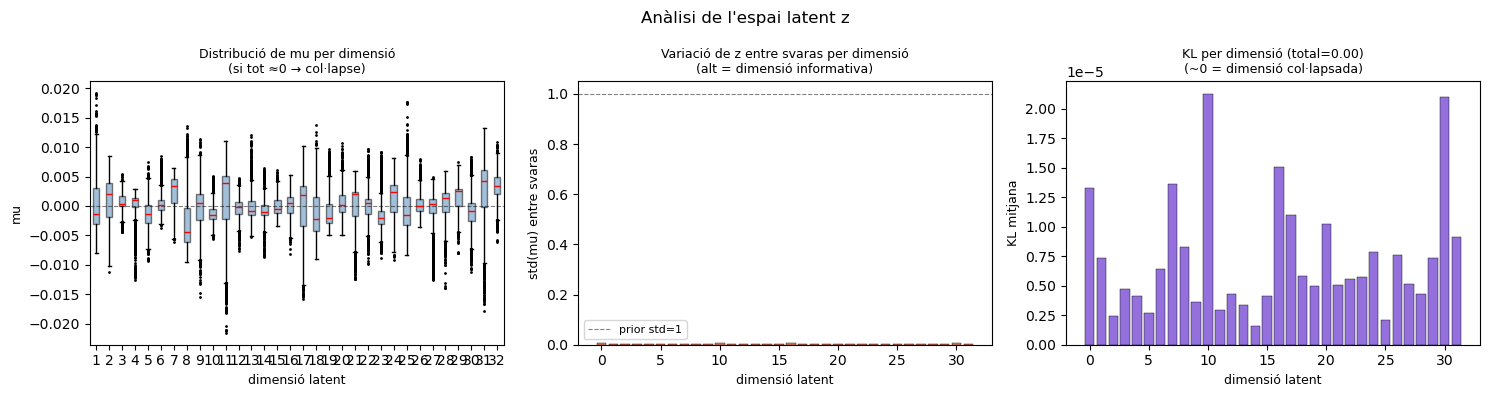

KL total: 0.000
Dimensions actives (KL>0.1): 0 / 32
Dimensions actives (KL>0.5): 0 / 32


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- 1. Distribució de mu (per dimensió) ---
ax = axes[0]
ax.boxplot(all_mu, vert=True, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.5),
           medianprops=dict(color="red"),
           flierprops=dict(marker=".", markersize=2))
ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("dimensió latent", fontsize=9)
ax.set_ylabel("mu", fontsize=9)
ax.set_title("Distribució de mu per dimensió\n(si tot ≈0 → col·lapse)", fontsize=9)

# --- 2. std de mu per dimensió (quanta variació entre svaras) ---
ax = axes[1]
mu_std = all_mu.std(axis=0)
ax.bar(range(len(mu_std)), mu_std, color="coral", edgecolor="black", linewidth=0.3)
ax.axhline(1.0, color="black", lw=0.8, ls="--", alpha=0.5, label="prior std=1")
ax.set_xlabel("dimensió latent", fontsize=9)
ax.set_ylabel("std(mu) entre svaras", fontsize=9)
ax.set_title("Variació de z entre svaras per dimensió\n(alt = dimensió informativa)", fontsize=9)
ax.legend(fontsize=8)

# --- 3. KL per dimensió = 0.5*(mu²+exp(logvar)-logvar-1) ---
ax = axes[2]
kl_per_dim = 0.5 * (all_mu**2 + np.exp(all_logvar) - all_logvar - 1)
kl_mean    = kl_per_dim.mean(axis=0)
ax.bar(range(len(kl_mean)), kl_mean, color="mediumpurple", edgecolor="black", linewidth=0.3)
ax.set_xlabel("dimensió latent", fontsize=9)
ax.set_ylabel("KL mitjana", fontsize=9)
ax.set_title(f"KL per dimensió (total={kl_mean.sum():.2f})\n(~0 = dimensió col·lapsada)", fontsize=9)

plt.suptitle("Anàlisi de l'espai latent z", fontsize=12)
plt.tight_layout()
plt.show()

print(f"KL total: {kl_mean.sum():.3f}")
print(f"Dimensions actives (KL>0.1): {(kl_mean > 0.1).sum()} / {len(kl_mean)}")
print(f"Dimensions actives (KL>0.5): {(kl_mean > 0.5).sum()} / {len(kl_mean)}")

/tmp/ipykernel_16864/3675664395.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_labels))


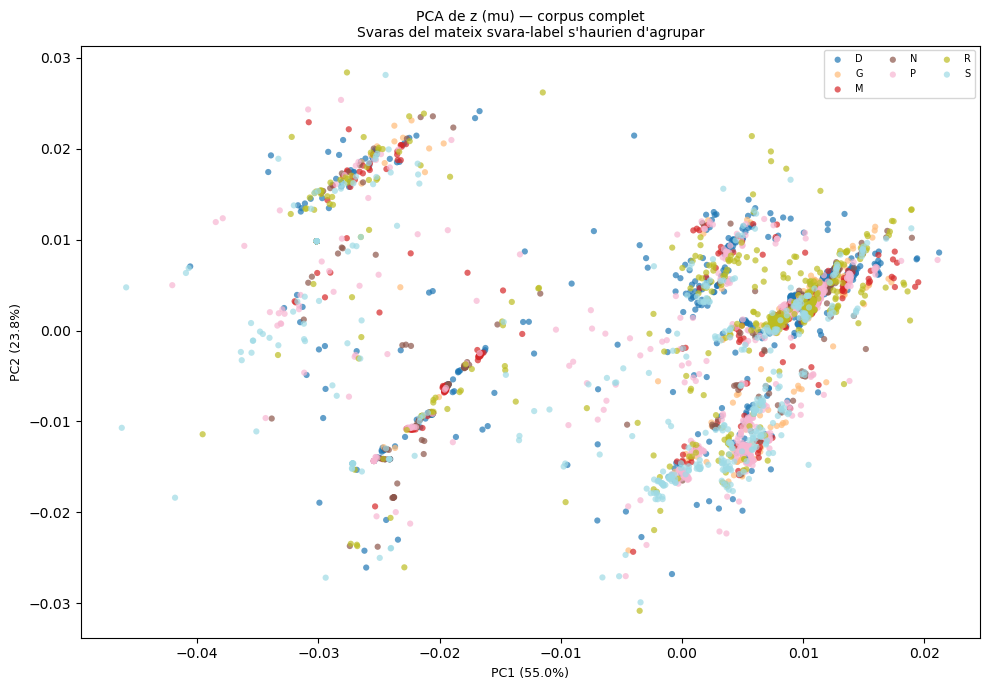

Variança explicada PC1+PC2: 78.8%


In [ ]:
# --- PCA de z — veure si svaras similars s'agrupen ---
from sklearn.decomposition import PCA

pca   = PCA(n_components=2)
z_2d  = pca.fit_transform(all_mu)

unique_labels = sorted(set(all_svara_labels))
cmap = plt.cm.get_cmap("tab20", len(unique_labels))
label_to_color = {l: cmap(i) for i, l in enumerate(unique_labels)}

fig, ax = plt.subplots(figsize=(10, 7))
for label in unique_labels:
    idx = [i for i, l in enumerate(all_svara_labels) if l == label]
    ax.scatter(z_2d[idx, 0], z_2d[idx, 1],
               label=label, color=label_to_color[label],
               s=20, alpha=0.7, edgecolors="none")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=9)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=9)
ax.set_title("PCA de z (mu) — corpus complet\nSvaras del mateix svara-label s'haurien d'agrupar", fontsize=10)
ax.legend(fontsize=7, ncol=3, loc="best")
plt.tight_layout()
plt.show()

print(f"Variança explicada PC1+PC2: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")

In [ ]:
# Zoom al nucli central del PCA (exclou outliers)
p5_x,  p95_x  = np.percentile(z_2d[:, 0], [5, 95])
p5_y,  p95_y  = np.percentile(z_2d[:, 1], [5, 95])
margin_x = (p95_x - p5_x) * 0.15
margin_y = (p95_y - p5_y) * 0.15

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (xlim, ylim, title) in zip(axes, [
    (None, None, "Visió global"),
    ((p5_x - margin_x, p95_x + margin_x),
     (p5_y - margin_y, p95_y + margin_y),
     "Zoom p5–p95 (sense outliers)"),
]):
    for label in unique_labels:
        idx = [i for i, l in enumerate(all_svara_labels) if l == label]
        ax.scatter(z_2d[idx, 0], z_2d[idx, 1],
                   label=label, color=label_to_color[label],
                   s=15, alpha=0.6, edgecolors="none")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=9)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=9)
    ax.set_title(title, fontsize=10)
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    ax.legend(fontsize=6, ncol=3, loc="best")

plt.suptitle("PCA de z (mu) — global vs zoom", fontsize=12)
plt.tight_layout()
plt.show()